In [3]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Blog Comments Prediction - PySpark ML") \
    .getOrCreate()

print(spark.version)

2.3.0.2.6.5.0-292


## Step 1. Load Cleaned Training Data
Read the cleaned training data CSV file (277 columns, with header) from the previous Data_clean.ipynb,it has total 49203 rows.

In [4]:
clean_csv_path = "/user/maria_dev/blog_project/blogData_train_clean.csv"

df = spark.read.option("header","true")\
        .option("inferSchema","true")\
        .option("sep",",")\
        .csv(clean_csv_path)

print("Data load")
print("row:",df.count())
print("column:",len(df.columns))

Data load
('row:', 49203)
('column:', 277)


## Step 2.  Combine  Vector and Split Dataset
The raw data has 276 feature columns, which is too many. Use VectorAssembler to combine all feature columns into one vector column "features". Split into training set (39470 rows) and test set (9733 rows) at 8:2 ratio.

In [5]:
from pyspark.ml.feature import VectorAssembler

# all input variable
feature_cols = [c for c in df.columns if c != "target"]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
data = assembler.transform(df).select("features", "target")
df.select("target").show(10)


+------+
|target|
+------+
|     3|
|    47|
|    44|
|     0|
|    12|
|     0|
|   132|
|     0|
|     0|
|     1|
+------+
only showing top 10 rows



## Step 3. Split Dataset and Check Target Distribution
Split the data into training and test sets at 8:2 ratio, then view the summary statistics of the target variable

In [6]:
train_df, test_df = data.randomSplit([0.8,0.2],seed=42)
print("Training set count:",train_df.count())
print("Test set count:",test_df.count())

('Training set count:', 39470)
('Test set count:', 9733)


In [5]:
# Compare target distribution between train and test
print("Train target stats:")
train_df.select("target").describe().show()
print("Test target stats:")
test_df.select("target").describe().show()

Train target stats:
+-------+-----------------+
|summary|           target|
+-------+-----------------+
|  count|            39470|
|   mean|6.908740815809476|
| stddev|39.40853576428092|
|    min|                0|
|    max|             1424|
+-------+-----------------+

Test target stats:
+-------+-----------------+
|summary|           target|
+-------+-----------------+
|  count|             9733|
|   mean|5.928696188225624|
| stddev|34.54672210998395|
|    min|                0|
|    max|              866|
+-------+-----------------+



## Step 4. Random Forest Model Tuning (Number of Trees)
Train Random Forest regression models with different tree counts (5 to 30) and compare R² and MAE on the test set. The highest test R² of 0.617 is achieved with 17 trees.

In [6]:
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator
import matplotlib.pyplot as plt

evaluator = RegressionEvaluator(labelCol="target", predictionCol="prediction", metricName="r2")
evaluator2 = RegressionEvaluator(labelCol="target", predictionCol="prediction", metricName="mae")
num_trees_list = [5,7,10, 15,17,20, 22, 25,27,30]
r2_scores = []
mae_scores = []

for num_trees in num_trees_list:
    rf = RandomForestRegressor(featuresCol="features",labelCol="target",numTrees=num_trees, maxDepth=10, seed=45)
    pred = rf.fit(train_df).transform(test_df)
    r2 = evaluator.evaluate(pred)
    mae = evaluator2.evaluate(pred)
    r2_scores.append(r2)
    mae_scores.append(mae)
    print("numTrees=", num_trees,", R2=", r2,", MAE=",mae)



('numTrees=', 5, ', R2=', 0.5973291718063584, ', MAE=', 5.148923607819372)
('numTrees=', 7, ', R2=', 0.47083018676734056, ', MAE=', 5.483221784680005)
('numTrees=', 10, ', R2=', 0.521017081565855, ', MAE=', 5.3532333621291395)
('numTrees=', 15, ', R2=', 0.5276100139727233, ', MAE=', 5.253697786981215)
('numTrees=', 17, ', R2=', 0.6170169266442523, ', MAE=', 5.041620768003425)
('numTrees=', 20, ', R2=', 0.5465592117320306, ', MAE=', 5.241751941008613)
('numTrees=', 22, ', R2=', 0.5541292777345862, ', MAE=', 5.201160347474417)
('numTrees=', 25, ', R2=', 0.5975858664042768, ', MAE=', 5.103854575241292)
('numTrees=', 27, ', R2=', 0.545867001187133, ', MAE=', 5.234835223437119)
('numTrees=', 30, ', R2=', 0.5348068690165939, ', MAE=', 5.1752623314496145)


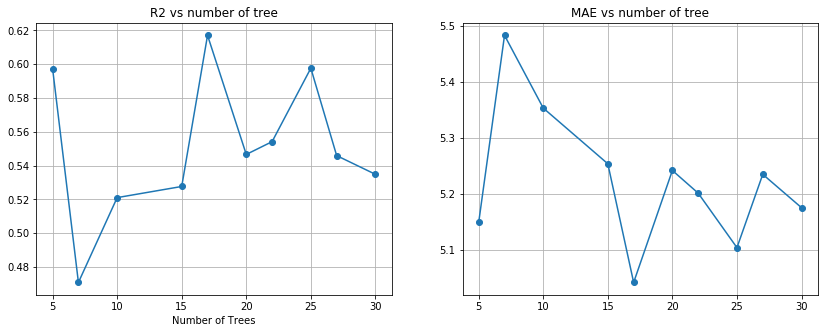

In [7]:
plt.figure(figsize=(14, 5))

plt.subplot(1,2,1)
plt.plot(num_trees_list,r2_scores, 'o-')
plt.xlabel('Number of Trees')
plt.title('R2 vs number of tree')
plt.grid(True)
plt.subplot(1,2,2)
plt.plot(num_trees_list,mae_scores, 'o-')
plt.title('MAE vs number of tree')
plt.grid(True)

plt.show()

+-------+------------------+
|summary|            target|
+-------+------------------+
|  count|             49203|
|   mean| 6.714875109241307|
| stddev|38.497199484822396|
|    min|                 0|
|    max|              1424|
+-------+------------------+

+------------------+
|          skewness|
+------------------+
|12.621376753170537|
+------------------+



## Step 5. PCA Dimensionality Reduction + Linear Regression
Apply log transformation to the target variable, reduce 276 features to 10-50 principal components using PCA, then train linear regression models. Results show the highest R² (0.442) at k=50, but overall performance is lower than Random Forest.

And as the number of principal components increases, R² grows more and more slowly,so i think the reasonable PCA range around 20 to 30.

In [9]:
from pyspark.ml.feature import PCA, StandardScaler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql.functions import log
import matplotlib.pyplot as plt

# Use existing train_df and test_df from previous cell
# Add log transformation to target
train = train_df.withColumn("target_log", log(train_df["target"] + 1))
test = test_df.withColumn("target_log", log(test_df["target"] + 1))

evaluator_r2 = RegressionEvaluator(labelCol="target_log", predictionCol="prediction", metricName="r2")
evaluator_mae = RegressionEvaluator(labelCol="target_log", predictionCol="prediction", metricName="mae")

pca_list = [10, 20, 30, 40, 50]
r2_scores = []
mae_scores = []

for k in pca_list:
    pca = PCA(inputCol="features", outputCol="pcaFeatures", k=k)
    train_pca = pca.fit(train).transform(train).select("pcaFeatures", "target_log")
    test_pca = pca.fit(train).transform(test).select("pcaFeatures", "target_log")
    lr = LinearRegression(featuresCol="pcaFeatures", labelCol="target_log", regParam=0.01, maxIter=20)
    pred = lr.fit(train_pca).transform(test_pca)
    r2 = evaluator_r2.evaluate(pred)
    mae = evaluator_mae.evaluate(pred)
    r2_scores.append(r2)
    mae_scores.append(mae)
    print("PCA k=", k, ", R2=", r2, ", MAE=", mae)

('PCA k=', 10, ', R2=', 0.33153352859096474, ', MAE=', 0.6321476766126911)
('PCA k=', 20, ', R2=', 0.41940345973987925, ', MAE=', 0.5771418842741256)
('PCA k=', 30, ', R2=', 0.4338370611217738, ', MAE=', 0.5682094239488564)
('PCA k=', 40, ', R2=', 0.4407309985486224, ', MAE=', 0.5644347371027029)
('PCA k=', 50, ', R2=', 0.4424185873288162, ', MAE=', 0.5639305749404201)


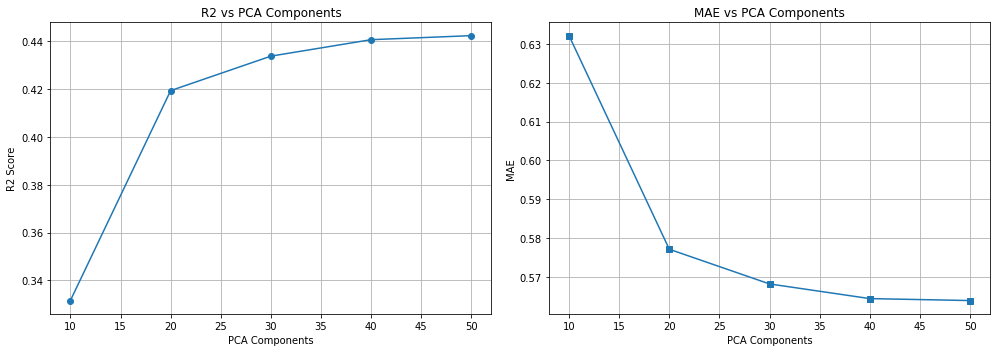

In [10]:

plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(pca_list,r2_scores,'o-')
plt.xlabel('PCA Components')
plt.ylabel('R2 Score')
plt.title('R2 vs PCA Components')
plt.grid(True)
plt.subplot(1,2,2)
plt.plot(pca_list,mae_scores,'s-')
plt.xlabel('PCA Components')
plt.ylabel('MAE')
plt.title('MAE vs PCA Components')
plt.grid(True)
plt.tight_layout()
plt.show()

## Step 6. Two-Stage Model: Classification + Regression
Because the proportion of zeros in the target is too high, i use a two-stage model. First: use a Random Forest classifier to predict whether the target is zero. Second: use a Random Forest regressor(or other regression model) on non-zero samples to predict actual values, then combine both results. The final model achieves an R² of 0.509 on the test set.

In [ ]:
from pyspark.sql.functions import skewness
df.select("target").describe().show()
df.select(skewness("target").alias("skewness")).show()

In [ ]:
zero_count = df.filter(df["target"] == 0).count()
total_count = df.count()
print("Number of target = 0:", zero_count)
print("Percentage of target = 0:", zero_count / total_count * 100, "%")

In [11]:
from pyspark.sql.functions import when, log, exp, col
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

train = train_df.withColumn("is_zero", when(train_df["target"] == 0, 1).otherwise(0))
train = train.withColumn("target_log", log(train["target"] + 1))
test = test_df.withColumn("is_zero", when(test_df["target"] == 0, 1).otherwise(0))
test = test.withColumn("target_log", log(test["target"] + 1))

# classification
clf = RandomForestClassifier(featuresCol="features", labelCol="is_zero", numTrees=17, maxDepth=10, seed=45)
clf_model = clf.fit(train.select("features", "is_zero"))
pred_clf = clf_model.transform(test.select("features", "is_zero")).select("features", "prediction", "is_zero")

# regression (only target>0)
train_pos = train.filter(train["target"] > 0).select("features", "target_log")
test_pos = test.filter(test["target"] > 0).select("features", "target")

reg = RandomForestRegressor(featuresCol="features", labelCol="target_log", numTrees=17, maxDepth=10, seed=45)
reg_model = reg.fit(train_pos)
pred_reg = reg_model.transform(test_pos).select("features", col("prediction").alias("pred_log"))


In [12]:

# combine
final_pred = pred_clf.join(pred_reg, ["features"], "left")
final_pred = final_pred.join(test.select("features", "target"), ["features"], "left")
final_pred = final_pred.withColumn("final_prediction", when(col("is_zero") == 1, 0).otherwise(exp(col("pred_log")) - 1))

# evaluation
evaluator_r2 = RegressionEvaluator(labelCol="target", predictionCol="final_prediction", metricName="r2")
evaluator_rmse = RegressionEvaluator(labelCol="target", predictionCol="final_prediction", metricName="rmse")
evaluator_mae = RegressionEvaluator(labelCol="target", predictionCol="final_prediction", metricName="mae")

print("R2:", evaluator_r2.evaluate(final_pred))
print("RMSE:", evaluator_rmse.evaluate(final_pred))
print("MAE:", evaluator_mae.evaluate(final_pred))

('R2:', 0.5088513651789)
('RMSE:', 24.13191193144769)
('MAE:', 4.079492009726724)


## Step 7. Multilayer Perceptron (MLP) Neural Network Model
Since PySpark's ML library only provides MLP for classification but not for regression, i switch to sklearn for MLP regression. Convert data to NumPy array format, standardize features and target variable, then train an MLP regression model with three hidden layers (20 neurons each). The model achieves an R² of 0.5929 on the training set and 0.5091 on the test set.

In [15]:
!pip install scikit-learn==0.20.4

DEPRECATION: Python 2.7 reached the end of its life on January 1st, 2020. Please upgrade your Python as Python 2.7 is no longer maintained. pip 21.0 will drop support for Python 2.7 in January 2021. More details about Python 2 support in pip can be found at https://pip.pypa.io/en/latest/development/release-process/#python-2-support pip 21.0 will remove support for this functionality.
     |████████████████████████████████| 5.5 MB 2.6 MB/s eta 0:00:01
     |████████████████████████████████| 24.8 MB 11.7 MB/s eta 0:00:01�█████████████████████▎  | 22.6 MB 4.9 MB/s eta 0:00:01
You should consider upgrading via the '/usr/bin/python -m pip install --upgrade pip' command.


In [13]:
#Convert features column of training and test sets to regular arrays
train_pdf=train_df.select("features","target").toPandas()
test_pdf=test_df.select("features","target").toPandas()

#Extract X (features) and y (target)
import numpy as np
X_train=np.stack(train_pdf["features"].apply(lambda v: v.toArray()).values)
y_train=train_pdf["target"].values
X_test=np.stack(test_pdf["features"].apply(lambda v: v.toArray()).values)
y_test=test_pdf["target"].values

print("Training set size:",X_train.shape)
print("Test set size:",X_test.shape)


('Training set size:', (39470, 276))
('Test set size:', (9733, 276))


In [14]:

from sklearn.preprocessing import StandardScaler

scaler_X=StandardScaler()
X_train_scaled=scaler_X.fit_transform(X_train)
X_test_scaled=scaler_X.transform(X_test)

# Target variable can also be standardized
scaler_y=StandardScaler()
y_train_scaled=scaler_y.fit_transform(y_train.reshape(-1,1)).ravel()
y_test_scaled=scaler_y.transform(y_test.reshape(-1,1)).ravel()

from sklearn.neural_network import MLPRegressor

mlp=MLPRegressor(
    hidden_layer_sizes=(20,20,20),
    activation='relu',
    solver='adam',               # for loss_curve
    alpha=2,
    batch_size=128,
    learning_rate='adaptive',
    max_iter=200,
    early_stopping=True,       
    validation_fraction=0.1,
    n_iter_no_change=20,       
    random_state=45,
    verbose=True
)

mlp.fit(X_train_scaled,y_train_scaled)
print("MLP training completed, iterations:",mlp.n_iter_)

/usr/lib64/python2.7/site-packages/sklearn/utils/validation.py:595: DataConversionWarning: Data with input dtype int32 was converted to float64 by StandardScaler.
  warnings.warn(msg, DataConversionWarning)


Iteration 1, loss = 0.79245525
Validation score: 0.401577
Iteration 2, loss = 0.57455381
Validation score: 0.401973
Iteration 3, loss = 0.48092707
Validation score: 0.463611
Iteration 4, loss = 0.43007138
Validation score: 0.493115
Iteration 5, loss = 0.40727217
Validation score: 0.443048
Iteration 6, loss = 0.38149687
Validation score: 0.446218
Iteration 7, loss = 0.36463457
Validation score: 0.484756
Iteration 8, loss = 0.35243395
Validation score: 0.461170
Iteration 9, loss = 0.34065922
Validation score: 0.489133
Iteration 10, loss = 0.34207232
Validation score: 0.445533
Iteration 11, loss = 0.32101879
Validation score: 0.481229
Iteration 12, loss = 0.32186226
Validation score: 0.461477
Iteration 13, loss = 0.31242278
Validation score: 0.424993
Iteration 14, loss = 0.30911407
Validation score: 0.490314
Iteration 15, loss = 0.30343672
Validation score: 0.469610
Iteration 16, loss = 0.29830706
Validation score: 0.497295
Iteration 17, loss = 0.30078060
Validation score: 0.484425
Iterat

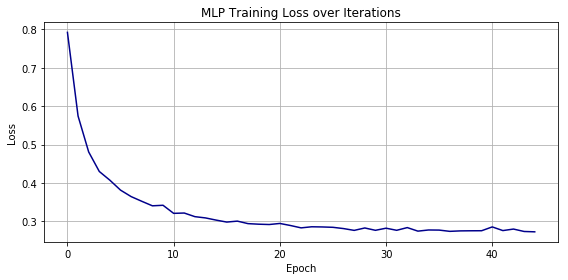

In [15]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 4))
plt.plot(mlp.loss_curve_, color='darkblue',linewidth=1.5)
plt.title('MLP Training Loss over Iterations')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.tight_layout()
plt.show()


In [16]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Predict (inverse transform for standardization)
y_train_pred_scaled=mlp.predict(X_train_scaled)
y_test_pred_scaled=mlp.predict(X_test_scaled)

y_train_pred=scaler_y.inverse_transform(y_train_pred_scaled.reshape(-1,1)).ravel()
y_test_pred=scaler_y.inverse_transform(y_test_pred_scaled.reshape(-1,1)).ravel()

# Evaluation
print("MLP training set R2:",round(r2_score(y_train,y_train_pred),4))
print("MLP test set R2:",round(r2_score(y_test,y_test_pred),4))
print("MLP test set RMSE:",round(np.sqrt(mean_squared_error(y_test,y_test_pred)),4))
print("MLP test set MAE:",round(mean_absolute_error(y_test,y_test_pred),4))

('MLP training set R2:', 0.5929)
('MLP test set R2:', 0.5091)
('MLP test set RMSE:', 24.2024)
('MLP test set MAE:', 6.3036)


## Step 8. Evaluate Models on Full Test Set
Read all cleaned test files (7624 rows total) and evaluate the three previously trained models on the full test set:

Random Forest (17 trees): R² of 0.384

Two-Stage Model (classification + regression): R² of 0.407

MLP Neural Network: R² of 0.345

Results show that the two-stage model performs best on the full test set.

In [17]:
# Read all clean test files from the folder
test_files_path = "/user/maria_dev/blog_project/clean_test/*.csv"

test_df_raw = spark.read.option("header","true")\
        .option("inferSchema","true")\
        .option("sep",",")\
        .csv(test_files_path)
print("testset columns",len(test_df_raw.columns))
# Apply the same VectorAssembler 
test_df2 = assembler.transform(test_df_raw).select("features", "target")


train_df = data

print("Test set count:",test_df.count())
print("Test set shape:",(test_df.count(), test_df.columns))

('testset columns', 277)
('Test set count:', 9733)
('Test set shape:', (9733, ['features', 'target']))


In [18]:
from pyspark.ml.regression import RandomForestRegressor

rf = RandomForestRegressor(featuresCol="features",labelCol="target",numTrees=17, maxDepth=15, seed=45)
pred = rf.fit(train_df).transform(test_df2)
r2 = evaluator.evaluate(pred)
mae = evaluator2.evaluate(pred)
print(r2,mae)

(0.38417505611008973, 5.502463834937587)


In [19]:
from pyspark.sql.functions import when,log,exp,col,coalesce,lit
from pyspark.ml.evaluation import RegressionEvaluator

test2=test_df2.withColumn("is_zero",when(col("target")==0,1).otherwise(0))
test2=test2.withColumn("target_log",log(col("target")+1))
test2_with_target=test2.select("features","target")

clf_pred=clf_model.transform(test2.select("features"))
clf_pred=clf_pred.select("features",col("prediction").alias("pred_is_zero"))

reg_pred=reg_model.transform(test2.select("features"))
reg_pred=reg_pred.select("features",col("prediction").alias("pred_log"))

final_pred=clf_pred.join(reg_pred,["features"],"left")
final_pred=final_pred.withColumn("final_prediction",
    when(col("pred_is_zero")==1,0)
    .otherwise(coalesce(exp(col("pred_log"))-1,lit(0))))

final_pred=final_pred.join(test2_with_target,["features"],"left")
final_pred=final_pred.filter(col("target").isNotNull())

evaluator_r2=RegressionEvaluator(labelCol="target",predictionCol="final_prediction",metricName="r2")
evaluator_rmse=RegressionEvaluator(labelCol="target",predictionCol="final_prediction",metricName="rmse")
evaluator_mae=RegressionEvaluator(labelCol="target",predictionCol="final_prediction",metricName="mae")

print("R2:",evaluator_r2.evaluate(final_pred))
print("RMSE:",evaluator_rmse.evaluate(final_pred))
print("MAE:",evaluator_mae.evaluate(final_pred))

('R2:', 0.40675081943175506)
('RMSE:', 2.3772095267737727)
('MAE:', 0.05128518389011196)


In [20]:
# Convert features column of test2 set to regular arrays
test2_pdf=test_df2.select("features","target").toPandas()

# Extract X (features) and y (target)
import numpy as np
X_test2=np.stack(test2_pdf["features"].apply(lambda v: v.toArray()).values)
y_test2=test2_pdf["target"].values

print("Test2 set size:",X_test2.shape)

# Use the already fitted scalers from training
X_test2_scaled=scaler_X.transform(X_test2)
y_test2_scaled=scaler_y.transform(y_test2.reshape(-1,1)).ravel()

# Make predictions
y_pred_scaled=mlp.predict(X_test2_scaled)
y_pred=scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1)).ravel()

from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

r2=r2_score(y_test2,y_pred)
rmse=np.sqrt(mean_squared_error(y_test2,y_pred))
mae=mean_absolute_error(y_test2,y_pred)

print("R2:",r2)
print("RMSE:",rmse)
print("MAE:",mae)

('Test2 set size:', (7624, 276))
('R2:', 0.3447179665661251)
('RMSE:', 24.689505904545662)
('MAE:', 6.0613670097917725)


## Step 9. Save Summary Results to MongoDB
Save the key results from model training (training rows, test rows, feature count, best R² and MAE) to a MongoDB database for future record and reference.

In [7]:
from pymongo import MongoClient
import pandas as pd

client = MongoClient("mongodb://localhost:27017/")
db = client["blog_project"]
col = db["summary"]

data = {
    "timestamp": pd.Timestamp.now(),
    "train_rows": train_df.count(),
    "test_rows": test_df.count(),
    "features": len(train_df.columns) - 1,
    "best_r2": 0.617016,
    "best_mae": 5.04162,
}

col.insert_one(data)
print("Saved to MongoDB")

Saved to MongoDB


In [15]:
!/usr/local/mongodb/bin/mongosh blog_project --eval "db.summary.find().pretty()"

]0;mongosh mongodb://127.0.0.1:27017/blog_project?directConnection=true&serverSelectionTimeoutMS=2000Current Mongosh Log ID:	6a380a20ff2aa4ddda7d03db
Connecting to:		mongodb://127.0.0.1:27017/blog_project?directConnection=true&serverSelectionTimeoutMS=2000&appName=mongosh+2.1.0
Using MongoDB:		6.0.5
Using Mongosh:		2.1.0

For mongosh info see: https://docs.mongodb.com/mongodb-shell/

 ------
   The server generated these startup warnings when booting
   2026-06-21T15:44:20.549+00:00: Access control is not enabled for the database. Read and write access to data and configuration is unrestricted
   2026-06-21T15:44:20.549+00:00: You are running this process as the root user, which is not recommended
   2026-06-21T15:44:20.549+00:00: This server is bound to localhost. Remote systems will be unable to connect to this server. Start the server with --bind_ip <address> to specify which IP addresses it should serve responses from, or with --bind_ip_all to bind to all interfaces. If this beha

In [17]:
! pip freeze > requirements.txt

DEPRECATION: Python 2.7 reached the end of its life on January 1st, 2020. Please upgrade your Python as Python 2.7 is no longer maintained. pip 21.0 will drop support for Python 2.7 in January 2021. More details about Python 2 support in pip can be found at https://pip.pypa.io/en/latest/development/release-process/#python-2-support pip 21.0 will remove support for this functionality.
